dx = 35000.0 m
dy = 35000.0 m


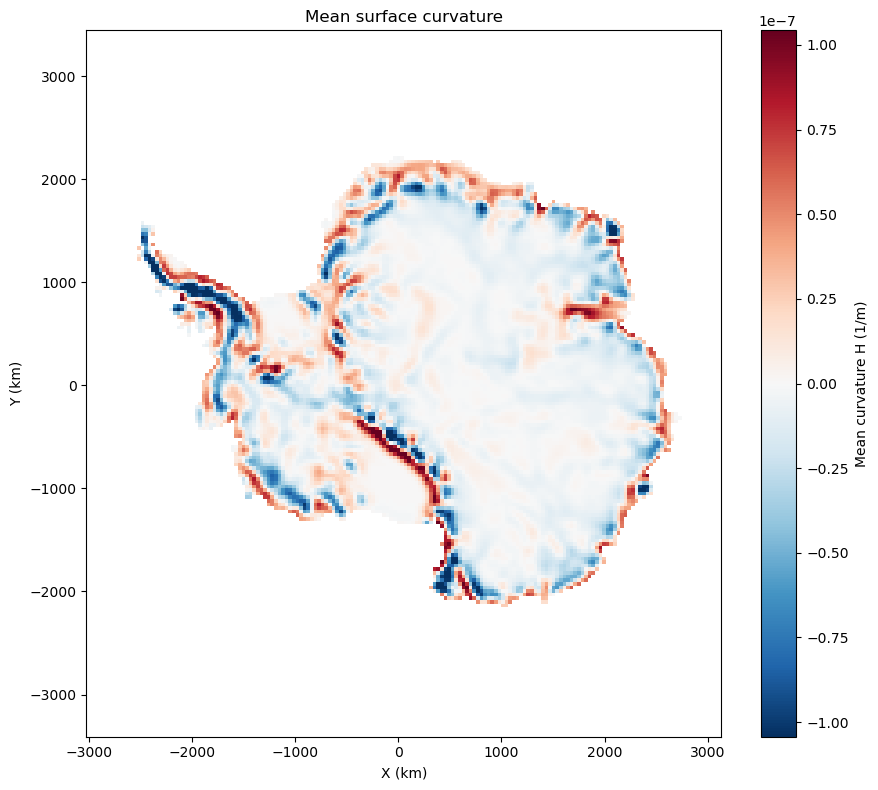

In [ ]:
#adapted script from 
#Credit: Sujith Royal
#https://github.com/sujithTSR/surface-curvature
#used this to investigate convex and concave sl.



import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

path = "/Users/dashakan/Desktop/scripts_AIS/MARcst-AN35km-176x148.cdf2"
ds = xr.open_dataset(path)
Z = ds["SH"].values.astype(float)   
X = ds["X"].values.astype(float)    
Y = ds["Y"].values.astype(float)    
dx = np.mean(np.diff(X)) * 1000.0
dy = np.mean(np.diff(Y)) * 1000.0
print(f"dx = {dx:.1f} m")
print(f"dy = {dy:.1f} m")
Zs = gaussian_filter(Z, sigma=1)
hy, hx = np.gradient(Zs, dy, dx)
hyy = np.gradient(hy, dy, axis=0)
hxx = np.gradient(hx, dx, axis=1)
hxy = np.gradient(hx, dy, axis=0) 
denom = 2.0 * (1.0 + hx**2 + hy**2)**1.5
denom = np.where(denom == 0, np.nan, denom)
H = ((1.0 + hy**2) * hxx - 2.0 * hx * hy * hxy + (1.0 + hx**2) * hyy) / denom
# positive H  means upward-convex under one normal choice
mask = ds["AIS"].values > 0
H_masked = np.where(mask, H, np.nan)

v = np.nanpercentile(np.abs(H_masked), 99)

plt.figure(figsize=(9, 8))
pcm = plt.pcolormesh(
    X, Y, H_masked,
    shading="auto",
    cmap="RdBu_r",
    vmin=-v, vmax=v
)
cbar = plt.colorbar(pcm)
cbar.set_label("Mean curvature H (1/m)")
plt.title("Mean surface curvature")
plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.axis("equal")
plt.tight_layout()
plt.show()

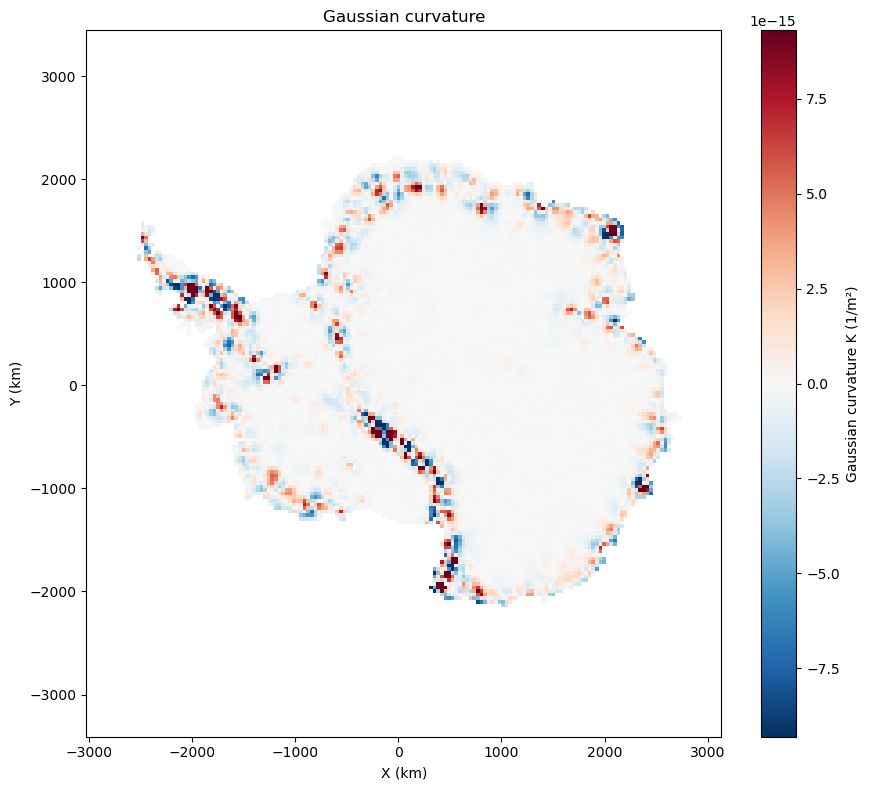

In [14]:
#Gaussian curvature 
K = (hxx * hyy - hxy**2) / (1.0 + hx**2 + hy**2)**2
K_masked = np.where(mask, K, np.nan)
v = np.nanpercentile(np.abs(K_masked), 99)
plt.figure(figsize=(9,8))
pcm = plt.pcolormesh(
    X, Y,
    K_masked,
    shading="auto",
    cmap="RdBu_r",
    vmin=-v, vmax=v
)
cbar = plt.colorbar(pcm)
cbar.set_label("Gaussian curvature K (1/m²)")
plt.title("Gaussian curvature")
plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.axis("equal")
plt.tight_layout()
plt.show()

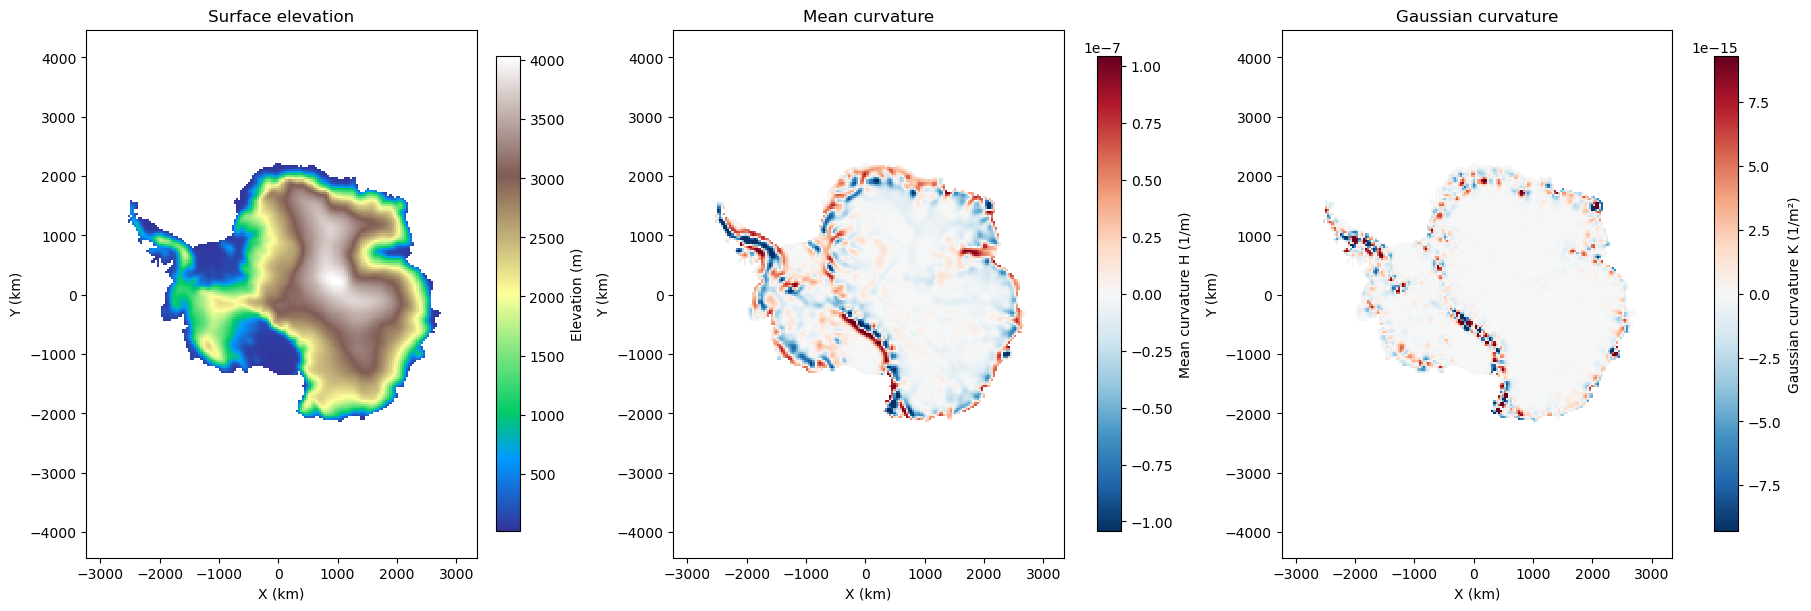

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
#elevation
Z_plot = np.where(mask, Zs, np.nan)
pcm0 = axes[0].pcolormesh(
    X, Y, Z_plot,
    shading="auto",
    cmap="terrain"
)
cbar0 = plt.colorbar(pcm0, ax=axes[0], shrink=0.9)
cbar0.set_label("Elevation (m)")
axes[0].set_title("Surface elevation")
axes[0].set_xlabel("X (km)")
axes[0].set_ylabel("Y (km)")
axes[0].axis("equal")
#curv
vH = np.nanpercentile(np.abs(H_masked), 99)

pcm1 = axes[1].pcolormesh(
    X, Y, H_masked,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vH, vmax=vH
)
cbar1 = plt.colorbar(pcm1, ax=axes[1], shrink=0.9)
cbar1.set_label("Mean curvature H (1/m)")
axes[1].set_title("Mean curvature")
axes[1].set_xlabel("X (km)")
axes[1].set_ylabel("Y (km)")
axes[1].axis("equal")

#Gaussian
vK = np.nanpercentile(np.abs(K_masked), 99)

pcm2 = axes[2].pcolormesh(
    X, Y, K_masked,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vK, vmax=vK
)
cbar2 = plt.colorbar(pcm2, ax=axes[2], shrink=0.9)
cbar2.set_label("Gaussian curvature K (1/m²)")
axes[2].set_title("Gaussian curvature")
axes[2].set_xlabel("X (km)")
axes[2].set_ylabel("Y (km)")
axes[2].axis("equal")

plt.show()